In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
import numpy as np
from scipy.spatial.distance import cdist

In [2]:
caminho_parquet = r"C:\Users\Pichau\INMET\TODAS_ESTACOES\TODAS_ESTACOES_CONCATENADO.parquet"

df = pd.read_parquet(caminho_parquet)

# Chuvas

In [4]:
df_intermediario = df.copy()

In [5]:
# Chuvas 

condicoes = [
    df_intermediario['Precip'] == 0,
    (df_intermediario['Precip'] > 0) & (df_intermediario['Precip'] < 25),
    df_intermediario['Precip'] >= 25
]

valores = ['Sem chuva', 'Chuva', 'Chuva Extrema']

df_intermediario['CHUVA'] = np.select(condicoes, valores, default='Desconhecido')

In [6]:
# Verificando a quantidade de Desconhecidos. Ausente ou - 9999.0 

# Contagem absoluta
contagem_absoluta = df_intermediario['CHUVA'].value_counts()

# Contagem relativa (proporção)
contagem_relativa = df_intermediario['CHUVA'].value_counts(normalize=True)

# Exibir os resultados
print("Contagem Absoluta:")
print(contagem_absoluta)

print("\nContagem Relativa:")
print(contagem_relativa)


Contagem Absoluta:
CHUVA
Sem chuva        492347
Chuva             43505
Desconhecido      29821
Chuva Extrema       199
Name: count, dtype: int64

Contagem Relativa:
CHUVA
Sem chuva        0.870068
Chuva            0.076881
Desconhecido     0.052699
Chuva Extrema    0.000352
Name: proportion, dtype: float64


In [7]:
df_intermediario = df_intermediario[df_intermediario['CHUVA'] != 'Desconhecido']

In [8]:
df_intermediario = df_intermediario.drop(columns=['Precip'])
df_intermediario = df_intermediario.drop(columns=['Dt_Hr'])
df_intermediario = df_intermediario.drop(columns=['timestamp'])
df_intermediario = df_intermediario.drop(columns=['Lat'])
df_intermediario = df_intermediario.drop(columns=['Long'])
df_intermediario = df_intermediario.drop(columns=['Alt'])

# Não quero explicar a variavel com a variavel 
df_intermediario = df_intermediario.drop(columns=['PRECIPITAÇÃO TOTAL primeira hora anterior'])
df_intermediario = df_intermediario.drop(columns=['PRECIPITAÇÃO TOTAL segunda hora anterior'])
df_intermediario = df_intermediario.drop(columns=['PRECIPITAÇÃO TOTAL terceira hora anterior'])



# Pressão - VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO - Kmeans

In [10]:
df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO']].isnull().sum()


VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO    394
dtype: int64

In [11]:
df_intermediario = df_intermediario.dropna(subset=['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO'])
df_intermediario = df_intermediario.dropna(subset=['VARIACAO SEGUNDA HORA ANTERIOR PRESSAO'])
df_intermediario = df_intermediario.dropna(subset=['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO'])




In [12]:

# Definir a variável para aplicar o K-Means
X = df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO']]

# Definir o número de clusters.
# Vou usar 2 para baixo, medio e alto. 
n_clusters = 3  

# Aplicar o K-Means
kmeans = KMeans(n_clusters = n_clusters, random_state= 10)
df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS'] = kmeans.fit_predict(X)

# Obter os centróides dos clusters
centroids = kmeans.cluster_centers_
print("Centróides de 'VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO': ", centroids)

# Atribuir rótulos aos clusters de temperatura com base nos centróides
df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS'] = df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS'].map({
    0: 'Medio',      # Cluster com centróide 0.52336831
    1: 'baixo',     # Cluster com 0.22598886
    2: 'Alto' ,     # Cluster com centróide 0.94487105
})

# ----------------------------------------------------------------------------------------------------

# Centroide, o cluster vai pertencer a menor distancia do centroid. 

Centróides de 'VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO':  [[0.16660775]
 [0.80650865]
 [0.39217988]]


In [13]:
centroids_manual = np.array([
    [0.52336831],
    [0.22598886],
    [0.99910914]
])

In [14]:
X_novo = df_intermediario[['VARIACAO SEGUNDA HORA ANTERIOR PRESSAO']]

# Calcular a distância de cada ponto aos centróides e encontrar o cluster mais próximo
df_intermediario['VARIACAO SEGUNDA HORA ANTERIOR PRESSAO CLUSTER K MEANS'] = np.argmin(
    cdist(X_novo, centroids_manual), axis=1
)

# Manter os mesmos rótulos de cluster
df_intermediario['VARIACAO SEGUNDA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS'] = df_intermediario[
    'VARIACAO SEGUNDA HORA ANTERIOR PRESSAO CLUSTER K MEANS'
].map({
    0: 'Medio',
    1: 'Baixo',
    2: 'Alto',
})

df_intermediario[['VARIACAO SEGUNDA HORA ANTERIOR PRESSAO', 
                        'VARIACAO SEGUNDA HORA ANTERIOR PRESSAO CLUSTER K MEANS', 
                        'VARIACAO SEGUNDA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS']]



,VARIACAO SEGUNDA HORA ANTERIOR PRESSAO,VARIACAO SEGUNDA HORA ANTERIOR PRESSAO CLUSTER K MEANS,VARIACAO SEGUNDA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS
18,0.0,1,Baixo
19,0.1,1,Baixo
35,0.0,1,Baixo
36,0.1,1,Baixo
37,0.3,1,Baixo
...,...,...,...
565867,0.4,0,Medio
565868,0.2,1,Baixo
565869,0.7,0,Medio
565870,1.0,2,Alto


In [15]:
X_novo = df_intermediario[['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO']]

# Calcular a distância de cada ponto aos centróides e encontrar o cluster mais próximo
df_intermediario['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS'] = np.argmin(
    cdist(X_novo, centroids_manual), axis=1
)

# Manter os mesmos rótulos de cluster
df_intermediario['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS'] = df_intermediario[
    'VARIACAO TERCEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS'
].map({
    0: 'Medio',
    1: 'Baixo',
    2: 'Alto',
})

df_intermediario[['VARIACAO TERCEIRA HORA ANTERIOR PRESSAO', 
                        'VARIACAO TERCEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS', 
                        'VARIACAO TERCEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS']]

,VARIACAO TERCEIRA HORA ANTERIOR PRESSAO,VARIACAO TERCEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS,VARIACAO TERCEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS
18,0.0,1,Baixo
19,0.0,1,Baixo
35,0.0,1,Baixo
36,0.0,1,Baixo
37,0.1,1,Baixo
...,...,...,...
565867,0.5,0,Medio
565868,0.4,0,Medio
565869,0.2,1,Baixo
565870,0.7,0,Medio


In [16]:
df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS'].value_counts()


VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO CLUSTER K MEANS - ROTULOS
Alto     241403
baixo    182726
Medio    110900
Name: count, dtype: int64

In [23]:
caminho_parquet = r"C:\Users\Pichau\INMET\TODAS_ESTACOES\df_intermediario.parquet"

df_intermediario.to_parquet(caminho_parquet, index=False)

# Silhueta 

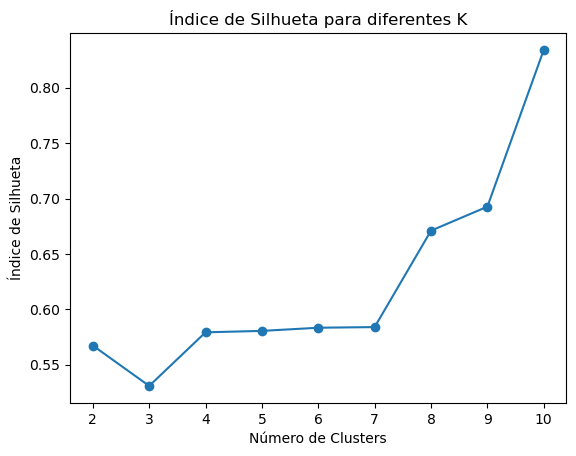

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

# Definir a variável para clustering
X = df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO']]

# Testar 
o índice de silhueta para diferentes números de clusters
silhouette_scores = []
K_range = range(2, 11)  # Testar de 2 a 5 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=10)
    labels = kmeans.fit_predict(X)
    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)

# Plotar o índice de silhueta
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Índice de Silhueta')
plt.title('Índice de Silhueta para diferentes K')
plt.show()
 